In [1]:
# Model
ENCODER_MODEL_PATH = "/project/lt200324-optmul/pluem/model/trocr-base-handwritten"
DECODER_MODEL_PATH = "/project/lt200324-optmul/pluem/model/huggingface_electra-small-25000-no-grad-small"

In [2]:
from transformers import (
    VisionEncoderDecoderModel,
    TrOCRProcessor,
    AutoModelForCausalLM,
    AutoTokenizer,
    AutoConfig,
    AdamW,
    get_linear_schedule_with_warmup,
)

tokenizer = AutoTokenizer.from_pretrained(DECODER_MODEL_PATH)

/lustrefs/disk/project/lt200324-optmul/pluem/env/lib/python3.10/site-packages/transformers/utils/hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [44]:
import pandas as pd

# Specify the path to your file
file_path = '/project/lt200324-optmul/pluem/version_3/dataset/wiki_en/wiki_en.txt'

# Read the file into a list
with open(file_path, 'r') as file:
    lines = file.readlines()

# Optionally, strip newline characters from each line
lines = [line.strip() for line in lines]

In [45]:
# Create a DataFrame from the list
df = pd.DataFrame(lines, columns=['text'])
df['text'] = df['text'].str.strip()
# Display the DataFrame
print(df)

                      text
0                 Valkyria
1         Chronicles III =
2          no Valkyria 3 :
3             Chronicles (
4         Japanese : , lit
...                    ...
13124064  ODST . Smith was
13124065    turned @@ game
13124066  the topic at the
13124067         2009 Game
13124068    Bungie 's 2014

[13124069 rows x 1 columns]


In [46]:
from tqdm import tqdm
# Enable tqdm to display progress
tqdm.pandas()

# Tokenize the text and calculate the desired ratio
def compute_ratio(row):
    tokens = tokenizer(row['text'], return_tensors='pt')
    input_ids_length = len(tokens["input_ids"][0])  # Get length of input_ids
    text_length = len(row['text'])
    return text_length / input_ids_length if input_ids_length > 0 else 0

# Use tqdm to show a progress bar while applying the function
df['length_ratio'] = df.progress_apply(compute_ratio, axis=1)

# Display the DataFrame
print(df)

100%|██████████| 13124069/13124069 [26:33<00:00, 8233.52it/s] 


                      text  length_ratio
0                 Valkyria      1.600000
1         Chronicles III =      2.666667
2          no Valkyria 3 :      1.666667
3             Chronicles (      2.400000
4         Japanese : , lit      1.777778
...                    ...           ...
13124064  ODST . Smith was      1.777778
13124065    turned @@ game      1.272727
13124066  the topic at the      2.000000
13124067         2009 Game      1.800000
13124068    Bungie 's 2014      1.555556

[13124069 rows x 2 columns]


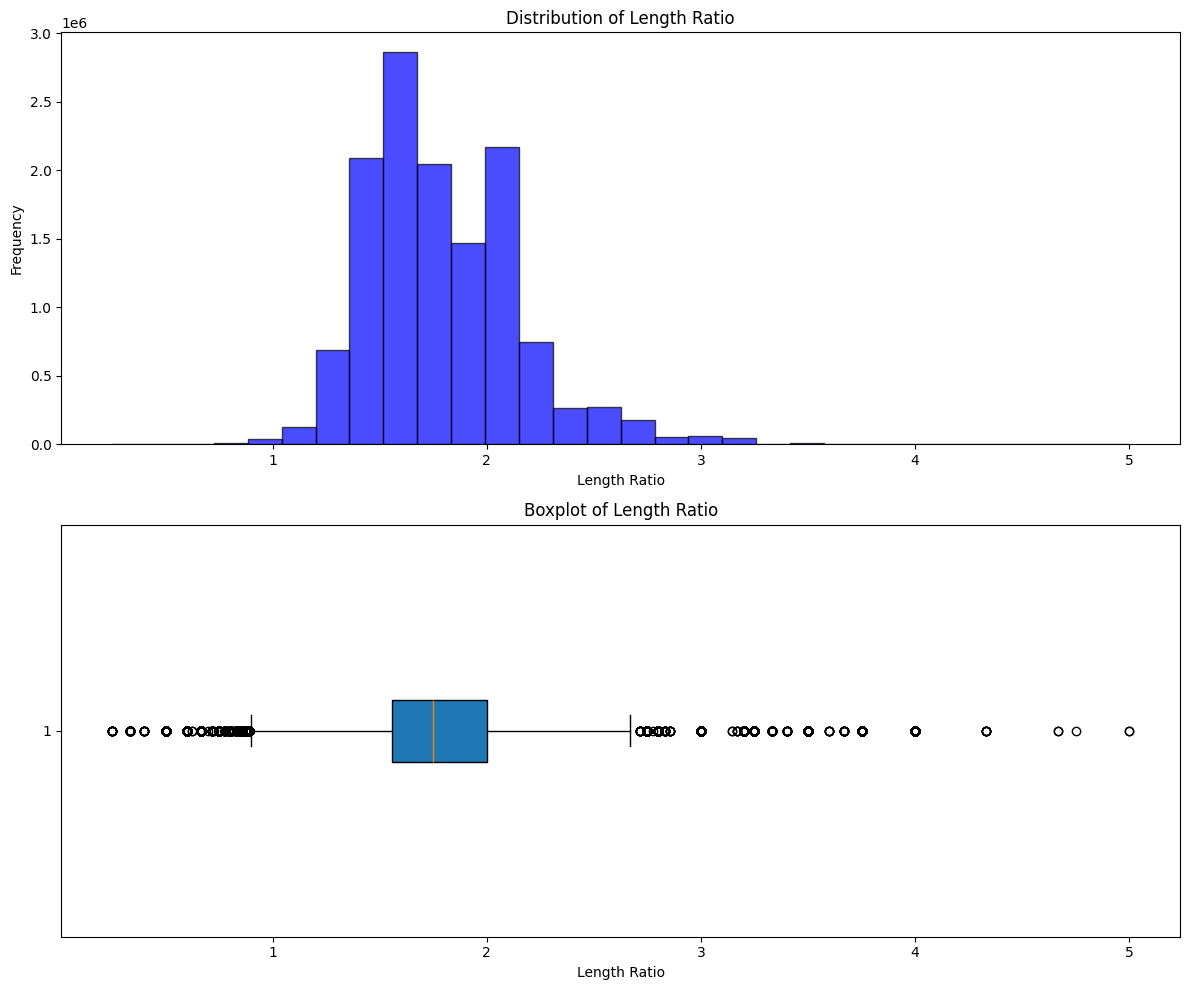

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with 'length_ratio' column

# Create a figure with two subplots: a histogram and a boxplot
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# Histogram
axs[0].hist(df['length_ratio'], bins=30, color='blue', alpha=0.7, edgecolor='black')
axs[0].set_title('Distribution of Length Ratio')
axs[0].set_xlabel('Length Ratio')
axs[0].set_ylabel('Frequency')

# Boxplot
axs[1].boxplot(df['length_ratio'], vert=False, patch_artist=True)
axs[1].set_title('Boxplot of Length Ratio')
axs[1].set_xlabel('Length Ratio')

# Show the plots
plt.tight_layout()
plt.show()


In [51]:
# Filter rows where length_ratio > 3.5
high_length_ratio_rows = df[df['length_ratio'] > 3]

# Display the filtered rows
print(high_length_ratio_rows)

                      text  length_ratio
47          development in      3.500000
74        director Takeshi      3.200000
106            translation      3.666667
116         development of      3.500000
118         Revolution for      3.500000
...                    ...           ...
13122801     Zone Magazine      3.250000
13122816    only interview      3.500000
13123459  A New University      3.200000
13123931    including Real      3.500000
13123982    Davis Internet      3.500000

[58319 rows x 2 columns]


In [52]:
# Drop rows where length_ratio > 4
df_filtered = df[df['length_ratio'] <= 3]

# Display the number of rows after filtering
print(f'Number of rows after dropping: {df_filtered.shape[0]}')

# Optionally, display the filtered DataFrame
print(df_filtered)

Number of rows after dropping: 13065750
                      text  length_ratio
0                 Valkyria      1.600000
1         Chronicles III =      2.666667
2          no Valkyria 3 :      1.666667
3             Chronicles (      2.400000
4         Japanese : , lit      1.777778
...                    ...           ...
13124064  ODST . Smith was      1.777778
13124065    turned @@ game      1.272727
13124066  the topic at the      2.000000
13124067         2009 Game      1.800000
13124068    Bungie 's 2014      1.555556

[13065750 rows x 2 columns]


In [53]:
text_data = "\n".join(df_filtered['text'])

# Specify the path where you want to save the file
output_file_path = '/project/lt200324-optmul/pluem/version_3/dataset/wiki_en/wiki_en.txt'

# Write the string to the .txt file
with open(output_file_path, 'w', encoding='utf-8') as file:
    file.write(text_data)

print(f'Data saved to {output_file_path}')

Data saved to /project/lt200324-optmul/pluem/version_3/dataset/wiki_en/wiki_en.txt
